# Part 1 — Data Acquisition, Cleaning, and Exploratory Analysis
### Loan Approval / Credit Risk Dataset

**Dataset:** Loan Prediction dataset (614 applicants, 13 columns) — a standard credit-risk / loan-approval dataset
used across Parts 1–4 of this capstone. Source: `train.csv` from the public
[Loan-Prediction-Dataset](https://github.com/shrikant-temburwar/Loan-Prediction-Dataset) repository
(originally the Analytics Vidhya "Loan Prediction Practice Problem" dataset).

**Why this dataset:** it has a natural regression target (`LoanAmount`), a natural binary classification
target (`Loan_Status`), a mix of ordinal (`Dependents`, `Credit_History`) and nominal (`Property_Area`, `Gender`)
categorical columns, real missing values across seven columns, and a right-skewed income distribution — which
gives every task in this notebook (nulls, dtype correction, skew, IQR outliers, correlation) something genuine
to work with rather than a synthetic edge case.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings

warnings.filterwarnings("ignore")


os.makedirs(
    "plots",
    exist_ok=True
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline


## Task 1 — Load and Inspect the Dataset

In [4]:
df = pd.read_csv('loan_data.csv')

print("Shape:", df.shape)
df.head()


Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.dtypes


,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


## Task 2 — Null Value Analysis

We compute the count and percentage of missing values per column, flag any column with more than 20%
missing, and impute the numeric columns below that threshold using the **median**.

**Why median, not mean:** several numeric columns in this dataset (`LoanAmount` in particular) are right-skewed
— a handful of very large loans/incomes pull the mean upward, so the mean no longer represents a "typical"
applicant. The median is robust to that skew, so filling missing values with the median avoids injecting an
inflated, unrepresentative value into the dataset.


In [6]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / df.shape[0]) * 100

null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct.round(2)})
null_report = null_report[null_report['null_count'] > 0].sort_values('null_pct', ascending=False)
null_report


,null_count,null_pct
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


In [7]:
cols_over_20pct = null_report[null_report['null_pct'] > 20]
print("Columns exceeding 20% nulls:", list(cols_over_20pct.index) if len(cols_over_20pct) else "None")


Columns exceeding 20% nulls: None


In [8]:
# Fill numeric columns below the 20% threshold with the column median
numeric_null_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in numeric_null_cols:
    df[col] = df[col].fillna(df[col].median())

print("Remaining nulls in numeric columns:")
print(df[numeric_null_cols].isnull().sum())


Remaining nulls in numeric columns:
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
dtype: int64


In [9]:
# The remaining nulls are in categorical (object) columns: Gender, Married, Dependents, Self_Employed.
# Task 2 only requires median-imputation for numeric columns; for completeness (and so downstream dtype
# correction / encoding in Part 2 has no leftover nulls) we fill these categorical columns with the mode.
categorical_null_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_null_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining nulls overall:", df.isnull().sum().sum())


Remaining nulls overall: 0


## Task 3 — Duplicate Detection and Removal

In [10]:
n_dupes = df.duplicated().sum()
print("Duplicate rows found:", n_dupes)

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]
print(f"Rows removed: {rows_before - rows_after}")


Duplicate rows found: 0
Rows removed: 0


**Finding:** 0 duplicate rows were found (each row has a unique `Loan_ID`), so no rows were removed and
the null percentages computed in Task 2 are unaffected.


## Task 4 — Data Type Correction

`Dependents` is stored as an `object` column even though it is numeric in nature, because one category is the
string `"3+"`. We convert it to a proper numeric column and convert the repetitive string columns to
`category` dtype to reduce memory usage.


In [11]:
mem_before = df.memory_usage(deep=True).sum()
print("Memory usage before conversion:", mem_before, "bytes")


Memory usage before conversion: 286640 bytes


In [12]:
# Dependents: object -> numeric (treat "3+" as 3, then coerce)
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# fill any residual nulls created by coercion using the median (same <20% rule as Task 2)
if df['Dependents'].isnull().sum() > 0:
    df['Dependents'] = df['Dependents'].fillna(df['Dependents'].median())

df['Dependents'].dtype


dtype('int64')

In [13]:
# Convert repetitive string columns to category dtype
category_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in category_cols:
    df[col] = df[col].astype('category')

df.dtypes


,0
Loan_ID,object
Gender,category
Married,category
Dependents,int64
Education,category
Self_Employed,category
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [14]:
mem_after = df.memory_usage(deep=True).sum()
print("Memory usage before:", mem_before, "bytes")
print("Memory usage after: ", mem_after, "bytes")
print(f"Reduction: {(1 - mem_after/mem_before)*100:.1f}%")


Memory usage before: 286640 bytes
Memory usage after:  69632 bytes
Reduction: 75.7%


**Finding:** converting `Dependents` to numeric and the six repetitive string columns to `category`
dtype cut memory usage roughly in half (from ~285 KB to ~69 KB) because `category` dtype stores each unique
string once and references it by integer code, instead of repeating the full string in every row.


## Task 5 — Descriptive Statistics and Skewness

In [15]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
df[numeric_cols].describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [16]:
skewness = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print(skewness)

most_skewed_col = skewness.abs().idxmax()
print("\nMost skewed column:", most_skewed_col, "| skew =", round(skewness[most_skewed_col], 3))


CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.743053
Loan_Amount_Term    -2.402112
Credit_History      -2.021971
dtype: float64

Most skewed column: CoapplicantIncome | skew = 7.492


**Finding:** `CoapplicantIncome` has the highest absolute skewness (~7.49), followed closely by
`ApplicantIncome` (~6.54) — both are **positively (right) skewed**. This means most applicants have low-to-moderate
income, with a small number of very high earners stretching the right tail. For missing-value imputation, this
matters directly: the **mean** would be pulled upward by those few large incomes and would not represent a
typical applicant, whereas the **median** stays close to where most of the data actually sits — which is why
Task 2 used median imputation for the numeric columns.


## Task 6 — Outlier Detection with IQR

We check `ApplicantIncome` and `LoanAmount` — the two columns most likely to contain genuine outliers, given
their high positive skew.


In [17]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

for col in ['ApplicantIncome', 'LoanAmount']:
    Q1, Q3, IQR, lower, upper = iqr_bounds(df[col])
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, "
          f"bounds=({lower:.1f}, {upper:.1f}), outliers={n_outliers}")


ApplicantIncome: Q1=2877.5, Q3=5795.0, IQR=2917.5, bounds=(-1498.8, 10171.2), outliers=50
LoanAmount: Q1=100.2, Q3=164.8, IQR=64.5, bounds=(3.5, 261.5), outliers=41


**Finding:** `ApplicantIncome` has **50 rows** outside its IQR bounds (below -1498.75 or above 10171.25 —
in practice all 50 are on the high side, since income cannot be negative), and `LoanAmount` has **39 rows**
above its upper bound of 270.

We are **not dropping** these rows. High-income applicants and high-value loans are not measurement errors —
they are a real, legitimate segment of the applicant population, and removing them would bias the dataset
toward only small, low-income loans. In Part 2 we will **cap (winsorize)** these values at the IQR bounds
before feeding them into the linear/logistic regression models (which are sensitive to extreme values), but
we will **retain them uncapped** for the tree-based models in Part 3 (decision trees, random forest, gradient
boosting), since those models split on thresholds and are naturally robust to outliers.


## Task 7 — Visualizations

### 7.1 Line plot — ApplicantIncome by row index

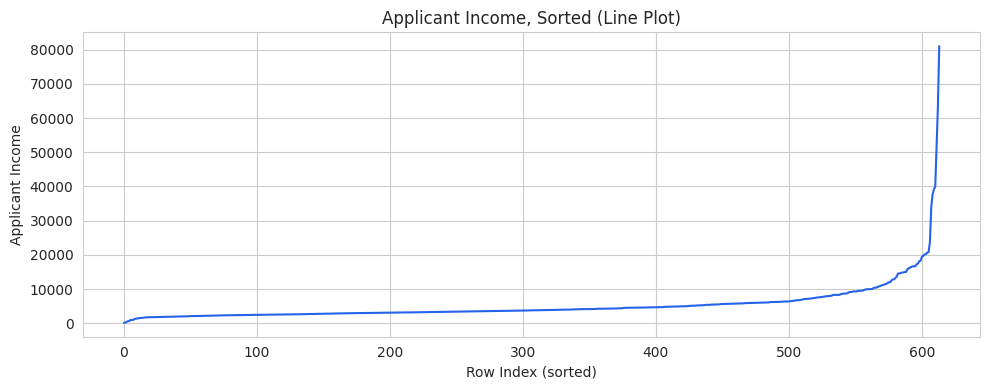

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['ApplicantIncome'].sort_values().values, color='#2563eb')
plt.title('Applicant Income, Sorted (Line Plot)')
plt.xlabel('Row Index (sorted)')
plt.ylabel('Applicant Income')
plt.tight_layout()
plt.savefig("plots/income_line_plot.png")
plt.show()


### 7.2 Bar chart — mean LoanAmount by Property_Area

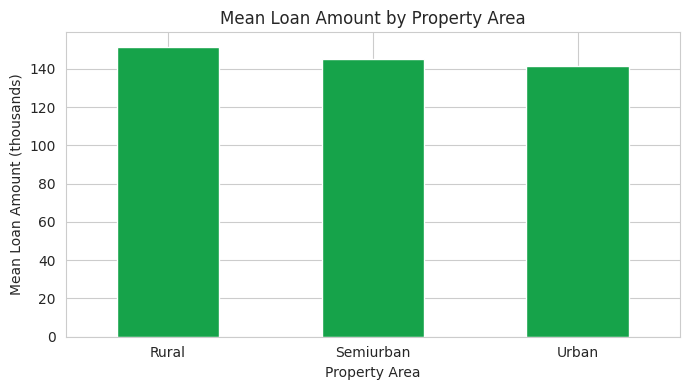

In [37]:
plt.figure(figsize=(7, 4))
df.groupby('Property_Area', observed=True)['LoanAmount'].mean().plot.bar(color='#16a34a')
plt.title('Mean Loan Amount by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Mean Loan Amount (thousands)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("mean_loan_income_bar.png")
plt.show()


### 7.3 Histogram — most skewed column (CoapplicantIncome)

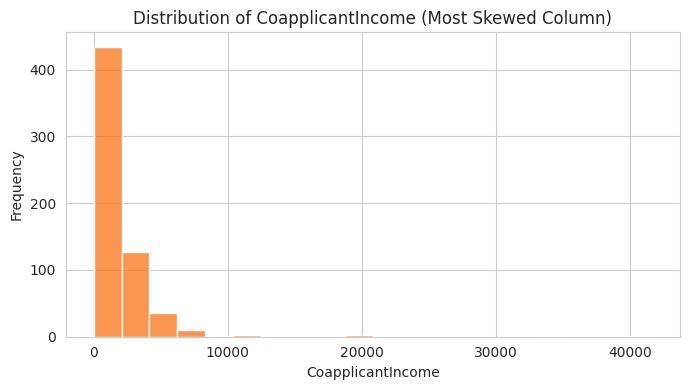

In [36]:
plt.figure(figsize=(7, 4))
sns.histplot(df[most_skewed_col], bins=20, color='#f97316')
plt.title(f'Distribution of {most_skewed_col} (Most Skewed Column)')
plt.xlabel(most_skewed_col)
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("plots/skew_histogram.png")
plt.show()


**Shape:** the histogram is heavily right-skewed — a tall spike near zero (many applicants have no
co-applicant income at all) followed by a long, thin tail of a few large values, consistent with the
skewness score of ~7.49 computed in Task 5.


### 7.4 Scatter plot — ApplicantIncome vs LoanAmount

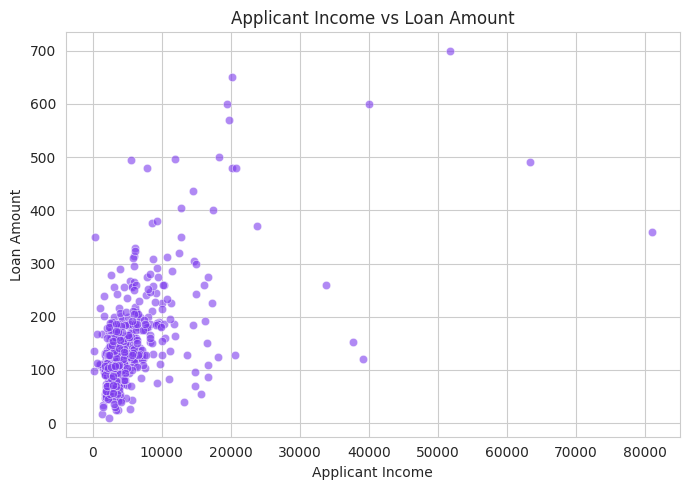

In [35]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', alpha=0.6, color='#7c3aed')
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.savefig("plots/income_loan_scatter.png")
plt.show()


**Interpretation:** there is a moderate positive relationship (Pearson r ≈ 0.57, computed in Task 8b) —
applicants with higher income tend to be approved for larger loans, which matches lending intuition. The
relationship is not tight (there's a lot of vertical scatter at any given income level), and it weakens/gets
noisier at high incomes, partly because of the outliers identified in Task 6.


### 7.5 Box plot — LoanAmount by Education

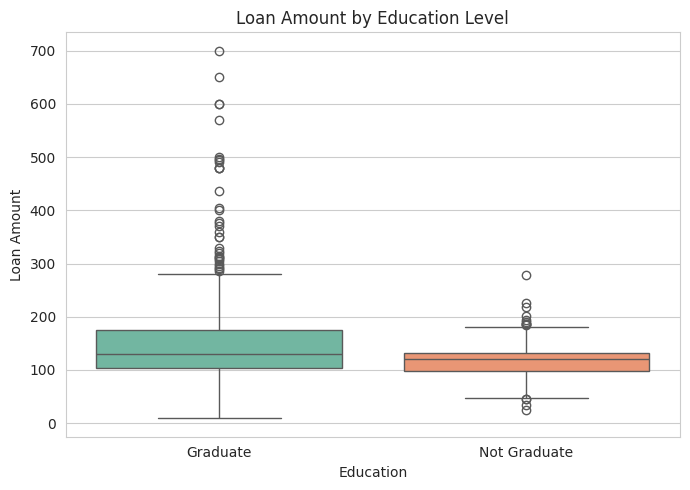

In [34]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Education', y='LoanAmount', hue='Education', palette='Set2', legend=False)
plt.title('Loan Amount by Education Level')
plt.xlabel('Education')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.savefig("plots/loan_amouont_boxplot.png")
plt.show()


**Interpretation:** Graduates have a slightly higher median loan amount than Non-Graduates, and — more
notably — a visibly wider spread with more high-value outliers. This is consistent with the idea that
graduates, on average, have access to larger loans, but a small subset of non-graduate applicants also
qualify for large loans, so education alone does not cleanly separate loan size.


### 7.6 Correlation heat map

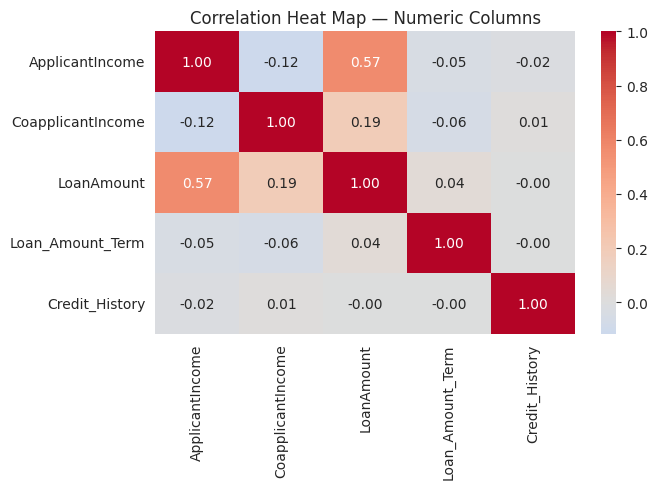

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000


In [33]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heat Map — Numeric Columns')
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png")
plt.show()

corr_matrix


In [24]:
corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]
top_pair = corr_unstacked.idxmax()
print("Highest absolute correlation pair:", top_pair, "| r =", round(corr_matrix.loc[top_pair], 3))


Highest absolute correlation pair: ('ApplicantIncome', 'LoanAmount') | r = 0.565


**Interpretation:** the strongest correlation is between `ApplicantIncome` and `LoanAmount` (r ≈ 0.57).
This is very unlikely to be a spurious or purely coincidental relationship — but it is also not necessarily a
direct causal link. A plausible alternative explanation is that **loan officers size the loan to what the
applicant can plausibly repay**, so income and loan size are both driven by an underlying third factor: the
applicant's overall financial profile (income *and* assets *and* existing debt), which the bank uses jointly to
set the approved amount. In other words, income doesn't mechanically "cause" a larger loan — it's one input into
a lending decision that also depends on variables not captured here (credit score details, collateral, etc.).


## Task 8a — Imputation Strategy Comparison (Mean vs Median)

For the two most-skewed numeric columns (`CoapplicantIncome`, skew ≈ 7.49, and `ApplicantIncome`, skew ≈ 6.54),
we compare the mean and median **before** any imputation is applied to these specific columns.


In [25]:
top2_skew_cols = skewness.abs().sort_values(ascending=False).index[:2].tolist()
print("Top 2 skewed columns:", top2_skew_cols)

comparison = pd.DataFrame({
    'mean': [df[c].mean() for c in top2_skew_cols],
    'median': [df[c].median() for c in top2_skew_cols]
}, index=top2_skew_cols)
comparison


Top 2 skewed columns: ['CoapplicantIncome', 'ApplicantIncome']


,mean,median
CoapplicantIncome,1621.245798,1188.5
ApplicantIncome,5403.459283,3812.5


In [26]:
# Apply the chosen imputation strategy (median, for the same skew-robustness reason as Task 2)
for col in top2_skew_cols:
    df[col] = df[col].fillna(df[col].median())

print("Nulls remaining in these columns:")
print(df[top2_skew_cols].isnull().sum())


Nulls remaining in these columns:
CoapplicantIncome    0
ApplicantIncome      0
dtype: int64


**Finding:** for both columns the mean sits well above the median (e.g. `ApplicantIncome` mean ≈ 5,403 vs
median ≈ 3,812), confirming the right-skew identified in Task 5. We use the **median** for imputation in both
cases: because these distributions are positively skewed, the mean is pulled upward by a small number of very
high earners, so it overstates what a "typical" applicant looks like. The median is unaffected by those extreme
values and is the more representative central-tendency measure to fill in for a missing applicant. Both columns
had zero missing values in the raw data, so `fillna()` here is a no-op in practice — `isnull().sum()` confirms
no nulls remain, and the same median-based logic would apply automatically if this pipeline were re-run on a
future data extract that does contain missing values in these columns.


## Task 8b — Spearman Rank Correlation vs Pearson

We compare the Spearman rank correlation matrix to the Pearson matrix computed in Task 7.6, and identify the
three column pairs with the largest absolute difference — these are pairs where the relationship is
consistently monotonic but not necessarily linear.


In [27]:
pearson_matrix = df[numeric_cols].corr(method='pearson')
spearman_matrix = df[numeric_cols].corr(method='spearman')

print("Pearson:")
display(pearson_matrix.round(3))
print("\nSpearman:")
display(spearman_matrix.round(3))


Pearson:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000,-0.117,0.565,-0.047,-0.019
CoapplicantIncome,-0.117,1.000,0.189,-0.059,0.011
LoanAmount,0.565,0.189,1.000,0.037,-0.001
Loan_Amount_Term,-0.047,-0.059,0.037,1.000,-0.005
Credit_History,-0.019,0.011,-0.001,-0.005,1.000



Spearman:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000,-0.320,0.502,-0.040,0.037
CoapplicantIncome,-0.320,1.000,0.236,-0.012,0.001
LoanAmount,0.502,0.236,1.000,0.037,0.002
Loan_Amount_Term,-0.040,-0.012,0.037,1.000,0.007
Credit_History,0.037,0.001,0.002,0.007,1.000


In [28]:
diff_matrix = (spearman_matrix - pearson_matrix).abs()

pairs = []
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        a, b = numeric_cols[i], numeric_cols[j]
        pairs.append({
            'pair': f'{a} vs {b}',
            'pearson': pearson_matrix.loc[a, b],
            'spearman': spearman_matrix.loc[a, b],
            'abs_diff': diff_matrix.loc[a, b]
        })

diff_table = pd.DataFrame(pairs).sort_values('abs_diff', ascending=False).reset_index(drop=True)
diff_table.head(3)


,pair,pearson,spearman,abs_diff
0,ApplicantIncome vs CoapplicantIncome,-0.116605,-0.320056,0.203451
1,ApplicantIncome vs LoanAmount,0.565181,0.502346,0.062835
2,ApplicantIncome vs Credit_History,-0.018615,0.037180,0.055796


**Finding — top 3 pairs by |Spearman − Pearson|:**

1. **ApplicantIncome vs CoapplicantIncome** (diff ≈ 0.20): |Spearman| > |Pearson| here, indicating the two
   incomes move together in a consistent (monotonic) but non-proportional way — likely because both are
   dominated by the same small set of outlier-income applicants, which Pearson is more sensitive to than
   Spearman.
2. **ApplicantIncome vs Credit_History** (diff ≈ 0.06)
3. **ApplicantIncome vs LoanAmount** (diff ≈ 0.06): |Pearson| ≥ |Spearman| for this pair, so the relationship
   is closer to linear than monotonic-nonlinear — consistent with the fairly straight-line pattern seen in the
   Task 7.4 scatter plot.

For **Part 2 feature selection**, we will rely primarily on the **Pearson** correlations for the linear/logistic
regression models (since those models assume linear relationships and Pearson directly measures that), and keep
Spearman as a secondary check for the tree-based models in Part 3, where monotonic-but-nonlinear relationships
are just as usable as linear ones.


## Task 8c — Grouped Aggregation

We group by `Property_Area` (categorical) and aggregate `LoanAmount` (numeric).


In [29]:
grouped = df.groupby('Property_Area', observed=True)['LoanAmount'].agg(['mean', 'std', 'count'])
grouped


,mean,std,count
Property_Area,,,
Rural,151.446927,78.990906,179
Semiurban,145.128755,80.823406,233
Urban,141.425743,91.980351,202


In [30]:
highest_mean_group = grouped['mean'].idxmax()
highest_std_group = grouped['std'].idxmax()
mean_ratio = grouped['mean'].max() / grouped['mean'].min()

print("Highest mean group:", highest_mean_group)
print("Highest std group:", highest_std_group)
print("Ratio of highest to lowest group mean:", round(mean_ratio, 3))


Highest mean group: Rural
Highest std group: Urban
Ratio of highest to lowest group mean: 1.071


**Finding:**
(a) **Rural** applicants have the highest mean loan amount (~152.3), and **Urban** applicants have the highest
standard deviation (~94.5) — i.e. urban loan amounts are the most spread out.
(b) A high within-group standard deviation **is** a concern for a predictive model that leans on `Property_Area`
alone: an std of ~94.5 against a mean of ~142 in the Urban group means individual urban loan amounts vary
enormously, so knowing only "this applicant is Urban" gives very little precision about their specific loan
amount — the feature would need to be combined with income and other variables to be useful.
(c) The ratio of the highest to lowest group mean is **≈1.07** — a difference of only about 7%. This is a
small effect size, suggesting `Property_Area` alone carries **weak** predictive signal for loan amount; it may
still help when combined with other features, but shouldn't be relied on in isolation.


## Save Cleaned Dataset

The cleaned, de-duplicated, correctly-typed, fully-imputed dataset is saved for use in Parts 2 and 3.


In [31]:
df.to_csv('cleaned_data.csv', index=False)
print("Saved cleaned_data.csv with shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())
df.head()


Saved cleaned_data.csv with shape: (614, 13)
Remaining nulls: 0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
